In [3]:
import pandas as pd
import numpy as np
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

In [4]:
def preparar_df(CSV_PATH, sim_year=2026):

    df = pd.read_csv(CSV_PATH)

    Q_DEMANDA_KWT = 2000       # 2 MWth = 2000 kWt
    DT_H = 1   
    df.columns = df.columns.str.strip()

    solar_col = [col for col in df.columns if "thermal power" in col.lower()][0]

    flow_col = [col for col in df.columns if "mass flow rate" in col.lower()][0]

    df = df.rename(columns={
        "Time stamp": "time_stamp_sam",
        solar_col: "Q_solar_kWt",
        flow_col: "m_dot_field_kg_s"
    })

    df["Q_solar_kWt"] = df["Q_solar_kWt"].clip(lower=0)

    df["Q_solar_W"] = df["Q_solar_kWt"] * 1000


    df["datetime"] = pd.to_datetime(
        str(sim_year) + " " + df["time_stamp_sam"],
        format="%Y %b %d, %I:%M %p"
    )

    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.weekday  

    df["is_weekday"] = df["weekday"] <= 4
    df["is_weekend"] = df["weekday"] >= 5

    df["is_operating_hour"] = (df["hour"] >= 6) & (df["hour"] < 22)

    df["is_operating"] = df["is_weekday"] & df["is_operating_hour"]


    df["Q_demand_kWt"] = np.where(df["is_operating"], Q_DEMANDA_KWT, 0)
    df["Q_demand_W"] = df["Q_demand_kWt"] * 1000


    df["Q_balance_kWt"] = df["Q_solar_kWt"] - df["Q_demand_kWt"]
    df["Q_balance_W"] = df["Q_balance_kWt"] * 1000

    df["Q_direct_process_kWt"] = np.minimum(df["Q_solar_kWt"], df["Q_demand_kWt"])
    df["Q_direct_process_W"] = df["Q_direct_process_kWt"] * 1000

    df["Q_deficit_kWt"] = np.maximum(df["Q_demand_kWt"] - df["Q_solar_kWt"], 0)
    df["Q_deficit_W"] = df["Q_deficit_kWt"] * 1000


    df["Q_excess_kWt"] = np.maximum(df["Q_solar_kWt"] - df["Q_demand_kWt"], 0)
    df["Q_excess_W"] = df["Q_excess_kWt"] * 1000


    df["Q_boiler_no_TES_kWt"] = df["Q_deficit_kWt"]
    df["Q_boiler_no_TES_W"] = df["Q_boiler_no_TES_kWt"] * 1000

    df["Q_dumped_no_TES_kWt"] = df["Q_excess_kWt"]
    df["Q_dumped_no_TES_W"] = df["Q_dumped_no_TES_kWt"] * 1000


    df["E_solar_kWh"] = df["Q_solar_kWt"] * DT_H
    df["E_demand_kWh"] = df["Q_demand_kWt"] * DT_H
    df["E_direct_process_kWh"] = df["Q_direct_process_kWt"] * DT_H
    df["E_deficit_kWh"] = df["Q_deficit_kWt"] * DT_H
    df["E_excess_kWh"] = df["Q_excess_kWt"] * DT_H
    df["E_boiler_no_TES_kWh"] = df["Q_boiler_no_TES_kWt"] * DT_H
    df["E_dumped_no_TES_kWh"] = df["Q_dumped_no_TES_kWt"] * DT_H


    cols_front = [
        "datetime",
        "time_stamp_sam",
        "month",
        "day",
        "hour",
        "weekday",
        "is_weekday",
        "is_weekend",
        "is_operating",
        "Q_solar_kWt",
        "Q_demand_kWt",
        "Q_balance_kWt",
        "Q_direct_process_kWt",
        "Q_deficit_kWt",
        "Q_excess_kWt",
        "Q_boiler_no_TES_kWt",
        "Q_dumped_no_TES_kWt",
    ]

    other_cols = [col for col in df.columns if col not in cols_front]
    df = df[cols_front + other_cols]

    E_demanda_anual = df["E_demand_kWh"].sum()
    E_solar_usada = df["E_direct_process_kWh"].sum()
    E_caldera = df["E_boiler_no_TES_kWh"].sum()
    E_dumped = df["E_dumped_no_TES_kWh"].sum()

    eta_caldera = 0.85

    E_gas_kWh = E_caldera / eta_caldera

    fraccion_solar = E_solar_usada / E_demanda_anual

    print("="*55)
    print("RESUMEN ANUAL - CASO SIN ALMACENAMIENTO")
    print("="*55)

    print(f"Energía demandada anual:        {E_demanda_anual:,.2f} kWh")
    print(f"Energía solar usada directa:    {E_solar_usada:,.2f} kWh")
    print(f"Energía térmica de caldera:     {E_caldera:,.2f} kWh")
    print(f"Energía química del gas:        {E_gas_kWh:,.2f} kWh")
    print(f"Energía solar descartada:       {E_dumped:,.2f} kWh")

    print("-"*55)

    print(f"Fracción solar anual:           {fraccion_solar*100:.2f} %")

    print("="*55)

    return df.reset_index(drop=True)


Con almacenamiento

In [5]:
def energia_tanque(Ts, Tf, rho_f, cp_f, D_estanque, dz, T_ref=150.0):
    A = np.pi * (D_estanque / 2) ** 2
    V_nodo = A * dz

    E_fluido = np.sum(
        rho_f * cp_f * eps * V_nodo * (Tf - T_ref)
    )

    E_solido = np.sum(
        rho_s * cp_s * (1 - eps) * V_nodo * (Ts - T_ref)
    )

    return E_fluido + E_solido

def modo_carga(Q_exceso_W, Ts, Tf, D, P_aire):
    dt = 1
    n_steps = 3600

    T_in = 170.0
    T_min = 150.0
    T_max = 170.0

    A = np.pi * (D / 2) ** 2

    cp_aire = CP.PropsSI("C", "T", T_in + 273.15, "P", P_aire, "Air")
    rho_aire = CP.PropsSI("D", "T", T_in + 273.15, "P", P_aire, "Air")

    m_punto_aire = Q_exceso_W / (cp_aire * (T_in - T_min))
    u = m_punto_aire / (rho_aire * A)

    CFL = u * dt / (eps * dz)
    if CFL > 1:
        print(f"Advertencia: CFL = {CFL:.2f}. Puede haber inestabilidad.")

    Ts_ini = Ts.copy()
    Tf_ini = Tf.copy()

    E_ini = energia_tanque(
        Ts_ini, Tf_ini, rho_aire, cp_aire, D, dz, T_ref=T_min
    )


    for _ in range(n_steps):

        Tf_old = Tf.copy()
        Ts_old = Ts.copy()

        dTfdz = np.zeros_like(Tf_old)

        dTfdz[0] = (Tf_old[0] - T_in) / dz
        dTfdz[1:] = (Tf_old[1:] - Tf_old[:-1]) / dz

        Tf = Tf_old + dt * (
            -(u / eps) * dTfdz
            + hv / (rho_aire * cp_aire * eps) * (Ts_old - Tf_old)
        )

        Ts = Ts_old + dt * (
            hv / (rho_s * cp_s * (1 - eps)) * (Tf_old - Ts_old)
        )

        Tf = np.clip(Tf, T_min, T_max)
        Ts = np.clip(Ts, T_min, T_max)

    E_fin_modelo = energia_tanque(
        Ts, Tf, rho_aire, cp_aire, D, dz, T_ref=T_min
    )

    E_abs_modelo = E_fin_modelo - E_ini
    E_disponible = Q_exceso_W * 3600

    if E_abs_modelo <= 0:
        Ts_final = Ts_ini
        Tf_final = Tf_ini
        E_absorbida_h = 0.0
        E_perdida_h = E_disponible
        
    elif E_abs_modelo > E_disponible:
        alpha = E_disponible / E_abs_modelo

        Ts_final = Ts_ini + alpha * (Ts - Ts_ini)
        Tf_final = Tf_ini + alpha * (Tf - Tf_ini)

        E_absorbida_h = E_disponible
        E_perdida_h = 0.0

    else:
        Ts_final = Ts
        Tf_final = Tf

        E_absorbida_h = E_abs_modelo
        E_perdida_h = E_disponible - E_abs_modelo

    return Ts_final, Tf_final, E_absorbida_h, E_perdida_h


def modo_descarga(Q_deficit_W, Ts, Tf, D, P_aire):
    dt = 1
    n_steps = 3600

    T_in = 150.0     
    T_min = 150.0
    T_max = 170.0

    A = np.pi * (D / 2) ** 2

    cp_aire = CP.PropsSI("C", "T", T_in + 273.15, "P", P_aire, "Air")
    rho_aire = CP.PropsSI("D", "T", T_in + 273.15, "P", P_aire, "Air")

    m_punto_aire = Q_deficit_W / (cp_aire * (T_max - T_min))
    u = m_punto_aire / (rho_aire * A)

    CFL = u * dt / (eps * dz)
    if CFL > 1:
        print(f"Advertencia descarga: CFL = {CFL:.2f}. Puede haber inestabilidad.")

    # Guardar estado inicial
    Ts_ini = Ts.copy()
    Tf_ini = Tf.copy()

    E_ini = energia_tanque(
        Ts_ini, Tf_ini, rho_aire, cp_aire, D, dz, T_ref=T_min
    )

    E_deficit = Q_deficit_W * 3600

    if E_ini <= 0:
        E_TES_h = 0.0
        E_caldera_h = E_deficit
        return Ts_ini, Tf_ini, E_TES_h, E_caldera_h

    for _ in range(n_steps):

        Tf_old = Tf.copy()
        Ts_old = Ts.copy()

        adv = np.zeros_like(Tf_old)

        adv[:-1] = (u / eps) * (Tf_old[1:] - Tf_old[:-1]) / dz

        adv[-1] = (u / eps) * (T_in - Tf_old[-1]) / dz

        Tf = Tf_old + dt * (
            adv
            + hv / (rho_aire * cp_aire * eps) * (Ts_old - Tf_old)
        )

        Ts = Ts_old + dt * (
            hv / (rho_s * cp_s * (1 - eps)) * (Tf_old - Ts_old)
        )

        Tf = np.clip(Tf, T_min, T_max)
        Ts = np.clip(Ts, T_min, T_max)

    E_fin_modelo = energia_tanque(
        Ts, Tf, rho_aire, cp_aire, D, dz, T_ref=T_min
    )

    E_desc_modelo = E_ini - E_fin_modelo

    if E_desc_modelo <= 0:
        Ts_final = Ts_ini
        Tf_final = Tf_ini

        E_TES_h = 0.0
        E_caldera_h = E_deficit


    elif E_desc_modelo > E_deficit:
        alpha = E_deficit / E_desc_modelo

        Ts_final = Ts_ini + alpha * (Ts - Ts_ini)
        Tf_final = Tf_ini + alpha * (Tf - Tf_ini)

        E_TES_h = E_deficit
        E_caldera_h = 0.0

    # Si el TES entrega menos que el déficit
    else:
        Ts_final = Ts
        Tf_final = Tf

        E_TES_h = E_desc_modelo
        E_caldera_h = E_deficit - E_desc_modelo

    return Ts_final, Tf_final, E_TES_h, E_caldera_h

def modo_reposo(Ts, Tf, P_aire):
    E_perdida_h = 0.0
    return Ts, Tf, E_perdida_h

In [6]:
def simular_con_TES(df, D, H=8.0, N=50, P_aire=10*101325):            

    A = np.pi * D**2 / 4
    dz = H / N

    Tf = np.ones(N) * 150.0
    Ts = np.ones(N) * 150.0

    perfiles_Ts = {}
    perfiles_Tf = {}

    fecha_perfil = "2026-01-15"
    horas_perfil = [8, 12, 16, 20]

    df = df.reset_index(drop=True)


    Energia_perdida = 0.0
    Energia_caldera_con_TES = 0.0
    Energia_TES_entregada = 0.0
    Energia_absorbida_TES = 0.0


    df["modo"] = ""

    df["E_perdida_J"] = 0.0
    df["E_caldera_TES_J"] = 0.0
    df["E_TES_entregada_J"] = 0.0
    df["E_absorbida_TES_J"] = 0.0

    df["Ts_arriba"] = np.nan
    df["Ts_abajo"] = np.nan
    df["Tf_arriba"] = np.nan
    df["Tf_abajo"] = np.nan


    for i in range(len(df)):

        Q_excedente = df.at[i, "Q_excess_W"]
        Q_deficit = df.at[i, "Q_deficit_W"]

        if Q_excedente > 0:

            Ts, Tf, E_abs_h, E_perdida_h = modo_carga(
                Q_excedente, Ts, Tf, D, P_aire
            )

            Energia_absorbida_TES += E_abs_h
            Energia_perdida += E_perdida_h

            df.at[i, "modo"] = "carga"
            df.at[i, "E_absorbida_TES_J"] = E_abs_h
            df.at[i, "E_perdida_J"] = E_perdida_h


        elif Q_deficit > 0:

            Ts, Tf, E_TES_h, E_caldera_h = modo_descarga(
                Q_deficit, Ts, Tf, D, P_aire
            )

            Energia_TES_entregada += E_TES_h
            Energia_caldera_con_TES += E_caldera_h

            df.at[i, "modo"] = "descarga"
            df.at[i, "E_TES_entregada_J"] = E_TES_h
            df.at[i, "E_caldera_TES_J"] = E_caldera_h


        else:

            Ts, Tf, E_perdida_h = modo_reposo(
                Ts, Tf, P_aire
            )

            Energia_perdida += E_perdida_h

            df.at[i, "modo"] = "reposo"
            df.at[i, "E_perdida_J"] = E_perdida_h


        # Guardar temperaturas al final de cada hora
        df.at[i, "Ts_arriba"] = Ts[0]
        df.at[i, "Ts_abajo"] = Ts[-1]
        df.at[i, "Tf_arriba"] = Tf[0]
        df.at[i, "Tf_abajo"] = Tf[-1]

        fecha_actual = df.at[i, "datetime"].strftime("%Y-%m-%d")
        hora_actual = df.at[i, "hour"]

        if fecha_actual == fecha_perfil and hora_actual in horas_perfil:
            perfiles_Ts[hora_actual] = Ts.copy()
            perfiles_Tf[hora_actual] = Tf.copy()


    E_caldera_no_TES_kWh = df["E_boiler_no_TES_kWh"].sum()
    E_dumped_no_TES_kWh = df["E_dumped_no_TES_kWh"].sum()
    E_solar_directa_kWh = df["E_direct_process_kWh"].sum()
    E_demanda_anual_kWh = df["E_demand_kWh"].sum()

    eta_caldera = 0.85
    PCI_gas_kWh_m3 = 9.5

    fraccion_solar_no_TES = E_solar_directa_kWh / E_demanda_anual_kWh

    E_gas_no_TES_kWh = E_caldera_no_TES_kWh / eta_caldera
    V_gas_no_TES_m3 = E_gas_no_TES_kWh / PCI_gas_kWh_m3


    E_perdida_TES_kWh = Energia_perdida / 3.6e6
    E_caldera_TES_kWh = Energia_caldera_con_TES / 3.6e6
    E_TES_entregada_kWh = Energia_TES_entregada / 3.6e6
    E_absorbida_TES_kWh = Energia_absorbida_TES / 3.6e6

    fraccion_solar_TES = (
        E_solar_directa_kWh + E_TES_entregada_kWh
    ) / E_demanda_anual_kWh

    E_gas_TES_kWh = E_caldera_TES_kWh / eta_caldera
    V_gas_TES_m3 = E_gas_TES_kWh / PCI_gas_kWh_m3


    E_dumped_weekend_no_TES_kWh = df.loc[
        df["is_weekend"], "E_dumped_no_TES_kWh"
    ].sum()

    E_dumped_weekend_TES_kWh = df.loc[
        df["is_weekend"], "E_perdida_J"
    ].sum() / 3.6e6

    ahorro_caldera_kWh = E_caldera_no_TES_kWh - E_caldera_TES_kWh
    ahorro_gas_m3 = V_gas_no_TES_m3 - V_gas_TES_m3

    balance_demanda_kWh = E_demanda_anual_kWh - (
        E_solar_directa_kWh + E_TES_entregada_kWh + E_caldera_TES_kWh
    )

    balance_solar_kWh = df["E_solar_kWh"].sum() - (
        E_solar_directa_kWh + E_absorbida_TES_kWh + E_perdida_TES_kWh
    )

    Ts_arriba_final = df["Ts_arriba"].iloc[-1]
    Ts_abajo_final = df["Ts_abajo"].iloc[-1]
    Tf_arriba_final = df["Tf_arriba"].iloc[-1]
    Tf_abajo_final = df["Tf_abajo"].iloc[-1]


    resultados = {
        "D_m": D,
        "H_m": H,
        "N": N,
        "Volumen_m3": A * H,

        "E_demanda_kWh": E_demanda_anual_kWh,
        "E_solar_directa_kWh": E_solar_directa_kWh,

        "fraccion_solar_no_TES": fraccion_solar_no_TES,
        "E_caldera_no_TES_kWh": E_caldera_no_TES_kWh,
        "E_dumped_no_TES_kWh": E_dumped_no_TES_kWh,
        "E_gas_no_TES_kWh": E_gas_no_TES_kWh,
        "V_gas_no_TES_m3": V_gas_no_TES_m3,

        "E_absorbida_TES_kWh": E_absorbida_TES_kWh,
        "E_TES_entregada_kWh": E_TES_entregada_kWh,
        "E_caldera_TES_kWh": E_caldera_TES_kWh,
        "E_gas_TES_kWh": E_gas_TES_kWh,
        "V_gas_TES_m3": V_gas_TES_m3,
        "E_perdida_TES_kWh": E_perdida_TES_kWh,
        "fraccion_solar_TES": fraccion_solar_TES,

        "E_dumped_weekend_no_TES_kWh": E_dumped_weekend_no_TES_kWh,
        "E_dumped_weekend_TES_kWh": E_dumped_weekend_TES_kWh,
        "ahorro_caldera_kWh": ahorro_caldera_kWh,
        "ahorro_gas_m3": ahorro_gas_m3,

        "balance_demanda_kWh": balance_demanda_kWh,
        "balance_solar_kWh": balance_solar_kWh,

        "Ts_arriba_final": Ts_arriba_final,
        "Ts_abajo_final": Ts_abajo_final,
        "Tf_arriba_final": Tf_arriba_final,
        "Tf_abajo_final": Tf_abajo_final,
    }


    print("="*70)
    print("RESUMEN ANUAL - CASO CON TES")
    print("="*70)

    print(f"Energía demandada anual:              {E_demanda_anual_kWh:,.2f} kWh")
    print(f"Energía solar directa al proceso:     {E_solar_directa_kWh:,.2f} kWh")
    print(f"Energía absorbida por TES:            {E_absorbida_TES_kWh:,.2f} kWh")
    print(f"Energía entregada por TES:            {E_TES_entregada_kWh:,.2f} kWh")
    print(f"Energía térmica de caldera con TES:   {E_caldera_TES_kWh:,.2f} kWh")
    print(f"Energía química del gas con TES:      {E_gas_TES_kWh:,.2f} kWh")
    print(f"Consumo gas natural con TES:          {V_gas_TES_m3:,.2f} m3/año")
    print(f"Energía solar descartada con TES:     {E_perdida_TES_kWh:,.2f} kWh")

    print("-"*70)

    print(f"Fracción solar con TES:               {fraccion_solar_TES:.4f}")
    print(f"Fracción solar con TES:               {fraccion_solar_TES*100:.2f} %")

    print("="*70)

    return resultados, df, perfiles_Ts, perfiles_Tf

In [7]:
def correr_caso_desde_archivo(csv_path, D, H=8.0, N=50, P_aire=10*101325, sim_year=2026, SM=None):
    df_base = preparar_df(csv_path, sim_year=sim_year)

    resultados, df_sim, perfiles_Ts, perfiles_Tf = simular_con_TES(
        df=df_base,
        D=D,
        H=H,
        N=N,
        P_aire=P_aire
    )

    if SM is not None:
        resultados["SM"] = SM

    resultados["archivo"] = csv_path

    return resultados, df_sim, perfiles_Ts, perfiles_Tf

archivos = [    
    ("1.0-results.csv", 1.00),
    ("1.25-results.csv", 1.25),
    ("1.5-results.csv", 1.50),
    ("1.75-results.csv", 1.75),
    ("2.0-results.csv", 2.00),
    ("2.25-results.csv", 2.25),
    ("2.5-results.csv", 2.50),
]

resultados_SM = []
dfs_SM = {}
perfiles_Ts_SM = {}
perfiles_Tf_SM = {}

rho_s = 2600
cp_s = 850
eps = 0.45
hv = 1200
dz = 8 / 50

for archivo, SM in archivos:
    print(f"Corriendo SM = {SM}...")

    res, df_temp, perfiles_Ts_temp, perfiles_Tf_temp = correr_caso_desde_archivo(
        csv_path=archivo,
        D=30,
        H=8,
        N=50,
        P_aire=10*101325,
        sim_year=2026,
        SM=SM
    )

    resultados_SM.append(res)
    dfs_SM[SM] = df_temp
    perfiles_Ts_SM[SM] = perfiles_Ts_temp
    perfiles_Tf_SM[SM] = perfiles_Tf_temp

df_resultados_SM = pd.DataFrame(resultados_SM)

Corriendo SM = 1.0...
RESUMEN ANUAL - CASO SIN ALMACENAMIENTO
Energía demandada anual:        8,352,000.00 kWh
Energía solar usada directa:    1,594,382.54 kWh
Energía térmica de caldera:     6,757,617.46 kWh
Energía química del gas:        7,950,138.19 kWh
Energía solar descartada:       603,016.12 kWh
-------------------------------------------------------
Fracción solar anual:           19.09 %
RESUMEN ANUAL - CASO CON TES
Energía demandada anual:              8,352,000.00 kWh
Energía solar directa al proceso:     1,594,382.54 kWh
Energía absorbida por TES:            602,990.28 kWh
Energía entregada por TES:            603,072.42 kWh
Energía térmica de caldera con TES:   6,154,545.04 kWh
Energía química del gas con TES:      7,240,641.23 kWh
Consumo gas natural con TES:          762,172.76 m3/año
Energía solar descartada con TES:     25.84 kWh
----------------------------------------------------------------------
Fracción solar con TES:               0.2631
Fracción solar con TES: 

DATOS PARA GRÁFICO 1 Y GRÁFICO 2
  SM fraccion_solar_no_TES_% fraccion_solar_TES_% V_gas_no_TES_m3 V_gas_TES_m3
1.00                   19.09                26.31         836,857      762,173
1.25                   38.18                51.86         639,410      497,899
1.50                   40.33                59.25         617,203      421,443
1.75                   41.11                64.85         609,078      363,580
2.00                   41.63                69.11         603,690      319,490
2.25                   41.98                72.52         600,116      284,217
2.50                   42.26                75.23         597,196      256,205


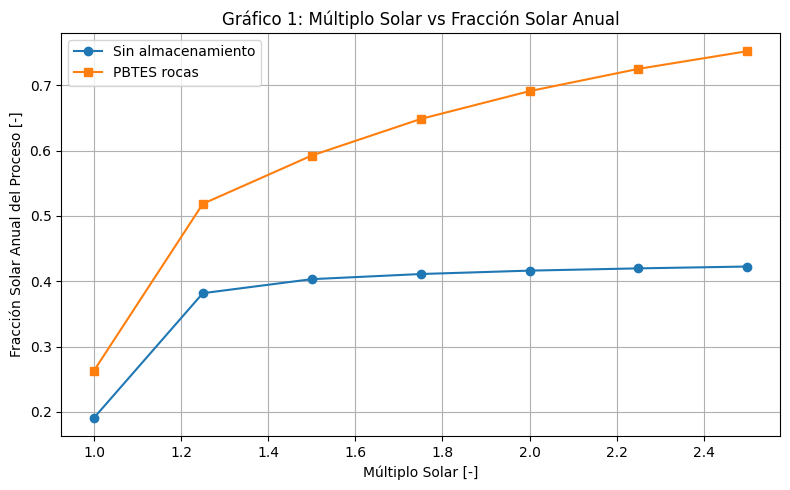

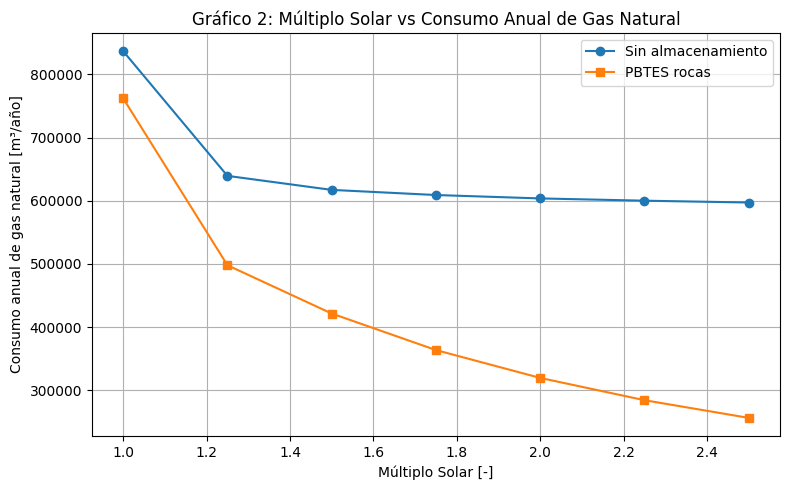

DATOS PARA GRÁFICO 3 - PERFIL Ts(z), SM = 2.5
Hora 8:00
Ts arriba: 170.00 °C
Ts abajo:  150.43 °C
Ts min:    150.43 °C
Ts max:    170.00 °C
--------------------------------------------------
Hora 12:00
Ts arriba: 170.00 °C
Ts abajo:  156.91 °C
Ts min:    156.91 °C
Ts max:    170.00 °C
--------------------------------------------------
Hora 16:00
Ts arriba: 170.00 °C
Ts abajo:  164.41 °C
Ts min:    164.41 °C
Ts max:    170.00 °C
--------------------------------------------------
Hora 20:00
Ts arriba: 170.00 °C
Ts abajo:  150.82 °C
Ts min:    150.82 °C
Ts max:    170.00 °C
--------------------------------------------------


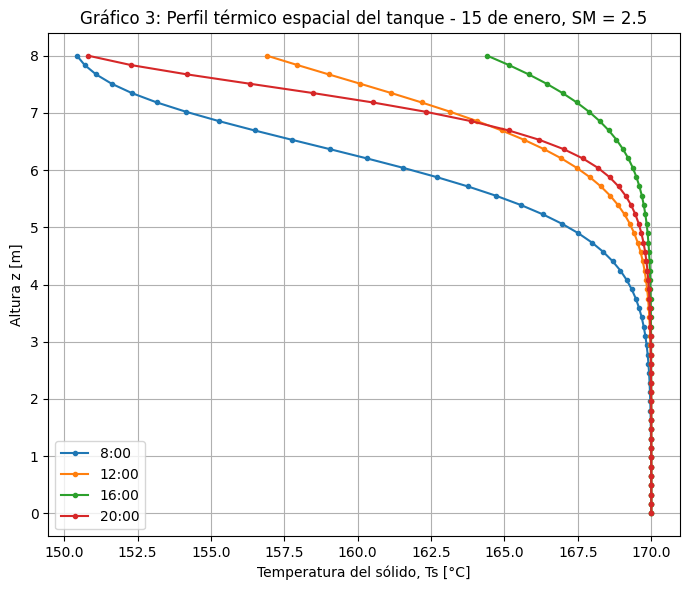

In [8]:

df_plot = df_resultados_SM.sort_values("SM").copy()

H_grafico = 8
N_grafico = 50
SM_perfil = 2.5
z = np.linspace(0, H_grafico, N_grafico)
 

print("="*90)
print("DATOS PARA GRÁFICO 1 Y GRÁFICO 2")
print("="*90)

cols_print = [
    "SM",
    "fraccion_solar_no_TES",
    "fraccion_solar_TES",
    "V_gas_no_TES_m3",
    "V_gas_TES_m3"
]

df_resumen_graficos = df_plot[cols_print].copy()
df_resumen_graficos["fraccion_solar_no_TES_%"] = df_resumen_graficos["fraccion_solar_no_TES"] * 100
df_resumen_graficos["fraccion_solar_TES_%"] = df_resumen_graficos["fraccion_solar_TES"] * 100

print(
    df_resumen_graficos[
        [
            "SM",
            "fraccion_solar_no_TES_%",
            "fraccion_solar_TES_%",
            "V_gas_no_TES_m3",
            "V_gas_TES_m3"
        ]
    ].to_string(
        index=False,
        formatters={
            "SM": "{:.2f}".format,
            "fraccion_solar_no_TES_%": "{:.2f}".format,
            "fraccion_solar_TES_%": "{:.2f}".format,
            "V_gas_no_TES_m3": "{:,.0f}".format,
            "V_gas_TES_m3": "{:,.0f}".format,
        }
    )
)

print("="*90)


plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["SM"],
    df_plot["fraccion_solar_no_TES"],
    marker="o",
    label="Sin almacenamiento"
)

plt.plot(
    df_plot["SM"],
    df_plot["fraccion_solar_TES"],
    marker="s",
    label="PBTES rocas"
)

if "fraccion_solar_PCM" in df_plot.columns:
    plt.plot(
        df_plot["SM"],
        df_plot["fraccion_solar_PCM"],
        marker="^",
        label="PBTES PCM"
    )

plt.xlabel("Múltiplo Solar [-]")
plt.ylabel("Fracción Solar Anual del Proceso [-]")
plt.title("Gráfico 1: Múltiplo Solar vs Fracción Solar Anual")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["SM"],
    df_plot["V_gas_no_TES_m3"],
    marker="o",
    label="Sin almacenamiento"
)

plt.plot(
    df_plot["SM"],
    df_plot["V_gas_TES_m3"],
    marker="s",
    label="PBTES rocas"
)

if "V_gas_PCM_m3" in df_plot.columns:
    plt.plot(
        df_plot["SM"],
        df_plot["V_gas_PCM_m3"],
        marker="^",
        label="PBTES PCM"
    )

plt.xlabel("Múltiplo Solar [-]")
plt.ylabel("Consumo anual de gas natural [m³/año]")
plt.title("Gráfico 2: Múltiplo Solar vs Consumo Anual de Gas Natural")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


perfiles_Ts = perfiles_Ts_SM[SM_perfil]

print("="*90)
print(f"DATOS PARA GRÁFICO 3 - PERFIL Ts(z), SM = {SM_perfil}")
print("="*90)

if len(perfiles_Ts) == 0:
    print("No se guardaron perfiles Ts para el 15 de enero.")
    print("Revisa que en simular_con_TES tengas:")
    print('fecha_perfil = "2026-01-15"')
    print("horas_perfil = [8, 12, 16, 20]")
else:
    for hora, Ts_profile in sorted(perfiles_Ts.items()):
        print(f"Hora {hora}:00")
        print(f"Ts arriba: {Ts_profile[0]:.2f} °C")
        print(f"Ts abajo:  {Ts_profile[-1]:.2f} °C")
        print(f"Ts min:    {np.min(Ts_profile):.2f} °C")
        print(f"Ts max:    {np.max(Ts_profile):.2f} °C")
        print("-"*50)

    plt.figure(figsize=(7, 6))

    for hora, Ts_profile in sorted(perfiles_Ts.items()):
        plt.plot(
            Ts_profile,
            z,
            marker="o",
            markersize=3,
            label=f"{hora}:00"
        )

    plt.xlabel("Temperatura del sólido, Ts [°C]")
    plt.ylabel("Altura z [m]")
    plt.title(f"Gráfico 3: Perfil térmico espacial del tanque - 15 de enero, SM = {SM_perfil}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

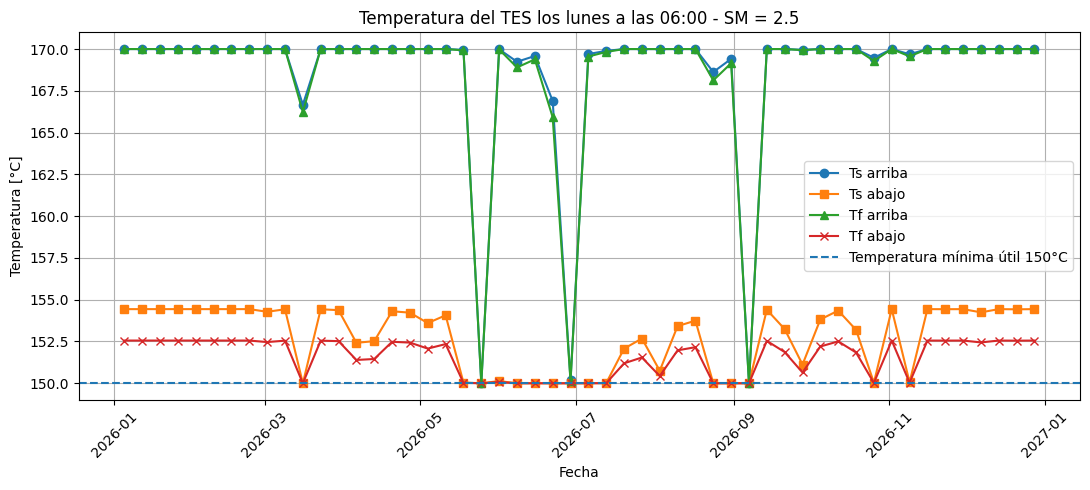

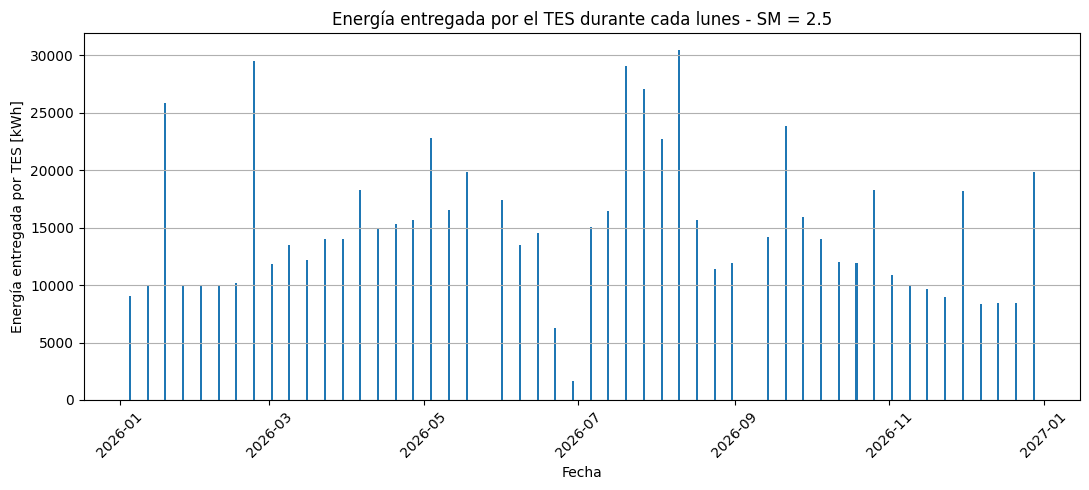

In [9]:

SM_objetivo = 2.5   
df_lunes = dfs_SM[SM_objetivo].copy()


df_lunes_6 = df_lunes[
    (df_lunes["weekday"] == 0) &
    (df_lunes["hour"] == 6)
].copy()

df_lunes_6["fecha"] = df_lunes_6["datetime"].dt.date


df_lunes_operacion = df_lunes[
    (df_lunes["weekday"] == 0) &
    (df_lunes["hour"] >= 6) &
    (df_lunes["hour"] < 22)
].copy()

df_lunes_operacion["fecha"] = df_lunes_operacion["datetime"].dt.date

energia_lunes_kWh = (
    df_lunes_operacion
    .groupby("fecha")["E_TES_entregada_J"]
    .sum()
    / 3.6e6
)

df_lunes_6["E_TES_entregada_lunes_kWh"] = df_lunes_6["fecha"].map(energia_lunes_kWh)


plt.figure(figsize=(11, 5))

plt.plot(
    df_lunes_6["fecha"],
    df_lunes_6["Ts_arriba"],
    marker="o",
    label="Ts arriba"
)

plt.plot(
    df_lunes_6["fecha"],
    df_lunes_6["Ts_abajo"],
    marker="s",
    label="Ts abajo"
)

plt.plot(
    df_lunes_6["fecha"],
    df_lunes_6["Tf_arriba"],
    marker="^",
    label="Tf arriba"
)

plt.plot(
    df_lunes_6["fecha"],
    df_lunes_6["Tf_abajo"],
    marker="x",
    label="Tf abajo"
)

plt.axhline(150, linestyle="--", label="Temperatura mínima útil 150°C")

plt.xlabel("Fecha")
plt.ylabel("Temperatura [°C]")
plt.title(f"Temperatura del TES los lunes a las 06:00 - SM = {SM_objetivo}")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 5))

plt.bar(
    df_lunes_6["fecha"],
    df_lunes_6["E_TES_entregada_lunes_kWh"]
)

plt.xlabel("Fecha")
plt.ylabel("Energía entregada por TES [kWh]")
plt.title(f"Energía entregada por el TES durante cada lunes - SM = {SM_objetivo}")
plt.grid(axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ANÁLISIS DINÁMICO DE LA CALDERA AUXILIAR EN INVIERNO - SM = 2.5
Periodo analizado: junio, julio y agosto
Horas totales analizadas:                         2,208 h
------------------------------------------------------------------------------------------
ENERGÍA TÉRMICA ENTREGADA POR CALDERA
------------------------------------------------------------------------------------------
Energía caldera sin TES:                          1,610,256.26 kWh
Energía caldera con TES:                          1,106,907.38 kWh
Ahorro térmico de caldera por TES:                503,348.88 kWh
Reducción porcentual de energía de caldera:       31.26 %
------------------------------------------------------------------------------------------
OPERACIÓN ENCENDIDA / APAGADA
------------------------------------------------------------------------------------------
Horas con caldera encendida sin TES:              835 h
Horas con caldera encendida con TES:              805 h
Partidas de caldera sin TES:        

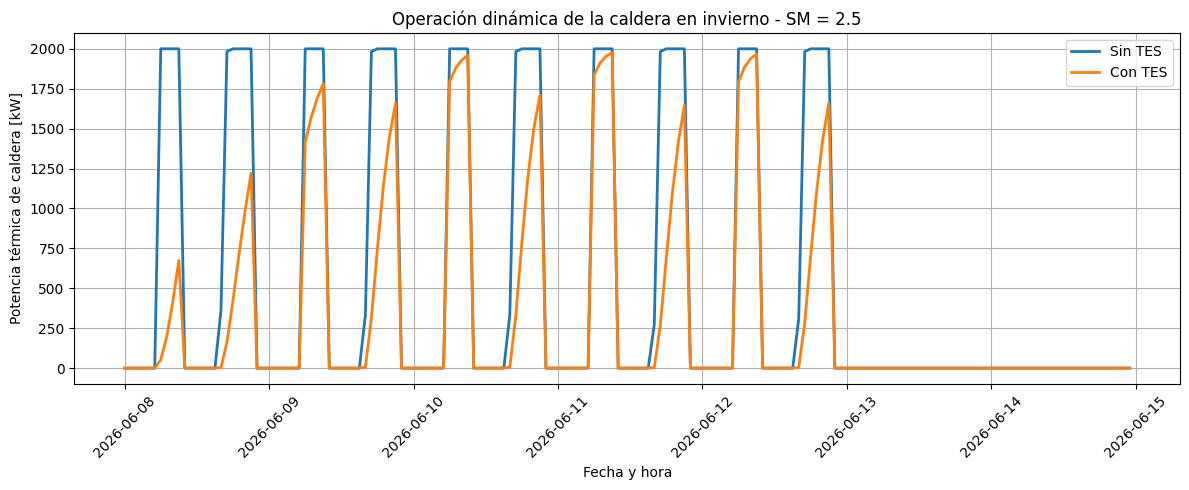

In [12]:

SM_objetivo = 2.5
df_caldera = dfs_SM[SM_objetivo].copy()

df_invierno = df_caldera[df_caldera["month"].isin([6, 7, 8])].copy()


df_invierno["Q_caldera_no_TES_kW"] = df_invierno["Q_boiler_no_TES_kWt"]

df_invierno["Q_caldera_TES_kW"] = df_invierno["E_caldera_TES_J"] / 3.6e6

umbral = 1.0

df_invierno["on_no_TES"] = df_invierno["Q_caldera_no_TES_kW"] > umbral
df_invierno["on_TES"] = df_invierno["Q_caldera_TES_kW"] > umbral

df_invierno["start_no_TES"] = df_invierno["on_no_TES"] & (~df_invierno["on_no_TES"].shift(1, fill_value=False))
df_invierno["start_TES"] = df_invierno["on_TES"] & (~df_invierno["on_TES"].shift(1, fill_value=False))

df_invierno["rampa_no_TES"] = df_invierno["Q_caldera_no_TES_kW"].diff().abs().fillna(0)
df_invierno["rampa_TES"] = df_invierno["Q_caldera_TES_kW"].diff().abs().fillna(0)


resumen_caldera = {
    "Horas operación sin TES": df_invierno["on_no_TES"].sum(),
    "Horas operación con TES": df_invierno["on_TES"].sum(),

    "Partidas sin TES": df_invierno["start_no_TES"].sum(),
    "Partidas con TES": df_invierno["start_TES"].sum(),

    "Rampa máxima sin TES [kW/h]": df_invierno["rampa_no_TES"].max(),
    "Rampa máxima con TES [kW/h]": df_invierno["rampa_TES"].max(),

    "Rampa promedio sin TES [kW/h]": df_invierno["rampa_no_TES"].mean(),
    "Rampa promedio con TES [kW/h]": df_invierno["rampa_TES"].mean(),

    "Desviación estándar sin TES [kW]": df_invierno["Q_caldera_no_TES_kW"].std(),
    "Desviación estándar con TES [kW]": df_invierno["Q_caldera_TES_kW"].std(),
}

# ======================================================
# PRINT ANÁLISIS DINÁMICO DE LA CALDERA EN INVIERNO
# ======================================================

E_caldera_no_TES_inv_kWh = df_invierno["Q_caldera_no_TES_kW"].sum()
E_caldera_TES_inv_kWh = df_invierno["Q_caldera_TES_kW"].sum()

ahorro_caldera_inv_kWh = E_caldera_no_TES_inv_kWh - E_caldera_TES_inv_kWh
ahorro_caldera_inv_pct = ahorro_caldera_inv_kWh / E_caldera_no_TES_inv_kWh * 100

reduccion_partidas = resumen_caldera["Partidas sin TES"] - resumen_caldera["Partidas con TES"]
reduccion_partidas_pct = reduccion_partidas / resumen_caldera["Partidas sin TES"] * 100

reduccion_rampa_prom = (
    resumen_caldera["Rampa promedio sin TES [kW/h]"] -
    resumen_caldera["Rampa promedio con TES [kW/h]"]
)

reduccion_rampa_prom_pct = (
    reduccion_rampa_prom /
    resumen_caldera["Rampa promedio sin TES [kW/h]"]
) * 100

reduccion_std = (
    resumen_caldera["Desviación estándar sin TES [kW]"] -
    resumen_caldera["Desviación estándar con TES [kW]"]
)

reduccion_std_pct = (
    reduccion_std /
    resumen_caldera["Desviación estándar sin TES [kW]"]
) * 100


print("="*90)
print(f"ANÁLISIS DINÁMICO DE LA CALDERA AUXILIAR EN INVIERNO - SM = {SM_objetivo}")
print("="*90)

print("Periodo analizado: junio, julio y agosto")
print(f"Horas totales analizadas:                         {len(df_invierno):,.0f} h")

print("-"*90)
print("ENERGÍA TÉRMICA ENTREGADA POR CALDERA")
print("-"*90)

print(f"Energía caldera sin TES:                          {E_caldera_no_TES_inv_kWh:,.2f} kWh")
print(f"Energía caldera con TES:                          {E_caldera_TES_inv_kWh:,.2f} kWh")
print(f"Ahorro térmico de caldera por TES:                {ahorro_caldera_inv_kWh:,.2f} kWh")
print(f"Reducción porcentual de energía de caldera:       {ahorro_caldera_inv_pct:.2f} %")

print("-"*90)
print("OPERACIÓN ENCENDIDA / APAGADA")
print("-"*90)

print(f"Horas con caldera encendida sin TES:              {resumen_caldera['Horas operación sin TES']:,.0f} h")
print(f"Horas con caldera encendida con TES:              {resumen_caldera['Horas operación con TES']:,.0f} h")

print(f"Partidas de caldera sin TES:                      {resumen_caldera['Partidas sin TES']:,.0f}")
print(f"Partidas de caldera con TES:                      {resumen_caldera['Partidas con TES']:,.0f}")
print(f"Reducción de partidas por TES:                    {reduccion_partidas:,.0f}")
print(f"Reducción porcentual de partidas:                 {reduccion_partidas_pct:.2f} %")

print("-"*90)
print("VARIABILIDAD Y RAMPAS DE LA CALDERA")
print("-"*90)

print(f"Rampa máxima sin TES:                             {resumen_caldera['Rampa máxima sin TES [kW/h]']:,.2f} kW/h")
print(f"Rampa máxima con TES:                             {resumen_caldera['Rampa máxima con TES [kW/h]']:,.2f} kW/h")

print(f"Rampa promedio sin TES:                           {resumen_caldera['Rampa promedio sin TES [kW/h]']:,.2f} kW/h")
print(f"Rampa promedio con TES:                           {resumen_caldera['Rampa promedio con TES [kW/h]']:,.2f} kW/h")
print(f"Reducción de rampa promedio:                      {reduccion_rampa_prom:,.2f} kW/h")
print(f"Reducción porcentual de rampa promedio:           {reduccion_rampa_prom_pct:.2f} %")

print(f"Desviación estándar potencia sin TES:             {resumen_caldera['Desviación estándar sin TES [kW]']:,.2f} kW")
print(f"Desviación estándar potencia con TES:             {resumen_caldera['Desviación estándar con TES [kW]']:,.2f} kW")
print(f"Reducción de variabilidad por TES:                {reduccion_std:,.2f} kW")
print(f"Reducción porcentual de variabilidad:             {reduccion_std_pct:.2f} %")

print("="*90)
print("INTERPRETACIÓN PARA EL INFORME")
print("="*90)

print(
    f"Durante invierno, la incorporación del TES reduce la energía térmica que debe "
    f"entregar la caldera desde {E_caldera_no_TES_inv_kWh:,.0f} kWh hasta "
    f"{E_caldera_TES_inv_kWh:,.0f} kWh, equivalente a una reducción de "
    f"{ahorro_caldera_inv_pct:.2f} %. "
)

print(
    f"Además, el número de partidas disminuye de "
    f"{resumen_caldera['Partidas sin TES']:,.0f} a "
    f"{resumen_caldera['Partidas con TES']:,.0f}, lo que implica una reducción de "
    f"{reduccion_partidas_pct:.2f} %. "
)

print(
    f"La rampa promedio de operación también cambia desde "
    f"{resumen_caldera['Rampa promedio sin TES [kW/h]']:,.2f} kW/h hasta "
    f"{resumen_caldera['Rampa promedio con TES [kW/h]']:,.2f} kW/h. "
    f"Esto indica que el TES amortigua parcialmente las variaciones del campo solar, "
    f"reduciendo la exigencia dinámica sobre la caldera."
)

print("="*90)

inicio_semana = "2026-06-08"
fin_semana = "2026-06-15"

df_invierno["datetime"] = pd.to_datetime(df_invierno["datetime"])

df_semana = df_invierno[
    (df_invierno["datetime"] >= inicio_semana) &
    (df_invierno["datetime"] < fin_semana)
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    df_semana["datetime"],
    df_semana["Q_caldera_no_TES_kW"],
    label="Sin TES",
    linewidth=2
)

plt.plot(
    df_semana["datetime"],
    df_semana["Q_caldera_TES_kW"],
    label="Con TES",
    linewidth=2
)

plt.xlabel("Fecha y hora")
plt.ylabel("Potencia térmica de caldera [kW]")
plt.title(f"Operación dinámica de la caldera en invierno - SM = {SM_objetivo}")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()